https://arxiv.org/pdf/2602.22801

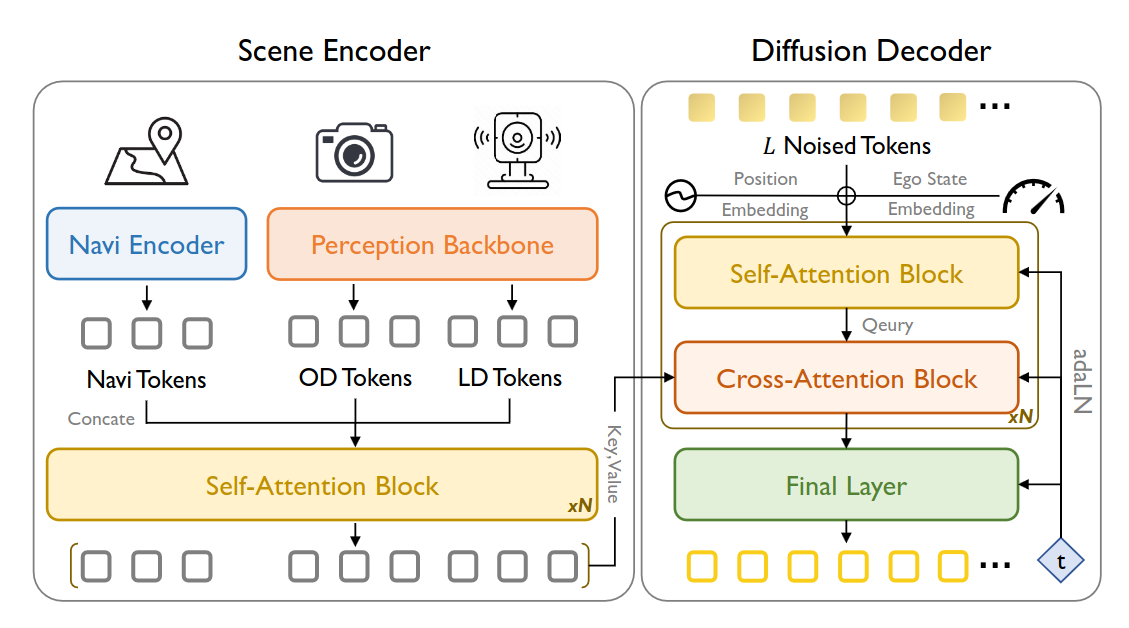

# Hyper Diffusion Planner (HDP) 论文详解

## 一、论文概况与核心思想

这篇题为 **《Unleashing the Potential of Diffusion Models for End-to-End Autonomous Driving》** 的论文由清华大学智能产业研究院（AIR）与小米汽车合作完成。其核心目标是：

- **系统性挖掘扩散模型作为端到端自动驾驶（E2E AD）规划器的潜力**，并部署到真实车辆上进行大规模路测验证。
- 通过严谨的对照实验，揭示三个关键设计原则：
  1. **扩散损失空间**：数据预测（τ₀-prediction）+ 数据损失（τ₀-loss）最适合规划任务。
  2. **轨迹表示**：混合损失（速度输出 + 路点监督）兼顾平滑性和空间准确性。
  3. **数据规模化**：在超大规模真实数据（~70M 帧）下，多模态生成能力涌现，闭环性能持续提升。
- 进一步提出**强化学习后训练**策略，利用奖励加权扩散损失提升安全性和鲁棒性。
- 最终框架 **Hyper Diffusion Planner (HDP)** 及 RL 增强版 **HDP-RL** 在 6 种城市场景、200 km 真实道路测试中，相比基础模型实现 **10 倍** 性能提升。

---

## 二、背景与动机

### 2.1 扩散模型在自动驾驶中的现状

扩散模型已在图像/视频生成、机器人决策中表现优异，并开始被用于自动驾驶规划。但现有研究存在两大问题：

1. **评估基准的局限性**：主流开源数据集（如 nuPlan）和仿真环境（如 NAVSIM）与真实部署在数据规模、轨迹多样性、评估协议上存在巨大差异。开环指标和伪闭环指标被广泛认为无法真实反映道路闭环性能。
2. **方法依赖先验和后处理**：许多工作为了在基准上取得好成绩，依赖规则后处理、预定义锚轨迹、显式目标条件等，掩盖了扩散模型本身的真实能力。

因此，**扩散模型作为自动驾驶规划器的真实上限仍不明确**。

### 2.2 本文目标

利用大规模真实车辆数据和严格的道路测试，系统研究扩散模型在 E2E AD 中的关键设计选择，不依赖任何手工先验或复杂后处理，只保留轻量平滑处理，以揭示扩散模型的真实潜力。

---

## 三、方法详解

### 3.1 基础模型架构

论文首先定义一个基础模型（Base Model），作为所有后续改进的起点。

**场景编码器（Scene Encoder）**：
- 采用多模态输入（摄像头 + LiDAR），通过 BEV 特征提取和 Transformer 查询生成两类感知 token：
  - **OD tokens**：目标检测（车辆、行人等）。
  - **LD tokens**：车道线检测。
- 与导航 token 拼接，经自注意力融合，得到潜在条件表示 $ C = \text{Enc}(s) $。

**扩散解码器（Diffusion Decoder）**：
- 基于 DiT 架构的 vanilla Transformer。
- 输入：条件 $ C $、当前自车状态、噪声轨迹 $ \tau_t $（长度 $ L $，每个时刻包含自车坐标系下的路点坐标和航向角 sin/cos）。
- 过程：将 $ \tau_t $ 分成 $ L $ 个 token，加入位置和速度嵌入，经自注意力后与 $ C $ 做交叉注意力，扩散时间步 $ t $ 通过 adaLN 注入。
- 输出：预测噪声 $ \epsilon $（或其它参数化），使用标准 $ \epsilon $-loss 训练。

### 3.2 扩散损失空间研究

**核心问题**：扩散模型可以预测不同的量（数据 $ \tau_0 $、流速度 $ v_t $、噪声 $ \epsilon $），损失也可以在不同空间计算（$ \tau_0 $-loss、$ v_t $-loss、$ \epsilon $-loss），形成 3×3 的设计矩阵。哪种组合最适合规划任务？

**实验设置**：训练 9 种组合，评估开环指标（ADE、FDE、舒适度、碰撞率等）。

**结果（表 1、图 3、图 4）**：
- 大多数组合能达到竞争性能，但 **τ₀-prediction + τ₀-loss** 表现突出（开环分数 75.27，远高于其他）。
- **快速收敛**：τ₀-prediction 模型收敛快且稳定，而 ϵ-prediction 和 v-prediction 训练不稳定。原因：规划轨迹位于低维流形，预测 $ \tau_0 $ 比预测高维的 $ \epsilon $ 或 $ v_t $ 更容易学习。
- **生成质量**：τ₀-prediction 生成的轨迹平滑、运动学一致；ϵ-prediction 模型常产生抖动和高频伪影，因为最终低噪声步的噪声估计困难。
- **失败案例**：ϵ-prediction + τ₀/v-loss 完全崩溃，因为损失目标方差极大（缩放因子 $ 1/\alpha_t $）。

**结论**：选择 τ₀-prediction + τ₀-loss 作为默认设计。

### 3.3 轨迹表示与混合损失

**问题**：直接预测路点（waypoints）虽然空间准确（ADE 低），但速度曲线抖动严重；预测速度（velocity）则平滑但空间精度略低。

**观察（图 5）**：
- 路点表示：全局几何结构好，但局部时间一致性差（速度曲线锯齿状）。
- 速度表示：平滑性好，舒适度高，但 ADE 略差。

**混合损失（Hybrid Loss）**：
- 模型输出速度 $ \tau^v_\theta $，同时监督：
  - 速度损失：$ \mathcal{L}_{\text{velocity}} = \mathbb{E}\|\tau^v_\theta - \tau^v_0\|^2 $
  - 路点损失：$ \mathcal{L}_{\text{waypoints}} = \mathbb{E}\|M \tau^v_\theta \Delta t - \tau^x_0\|^2 $，其中 $ M $ 是下三角积分矩阵，将速度积分为路点。
- 总损失：$ \mathcal{L}_{\text{hybrid}} = \mathcal{L}_{\text{velocity}} + \omega \cdot \mathcal{L}_{\text{waypoints}} $

**理论保证（定理 4.2）**：
- 证明混合损失等价于一个 $ P $-范数下的分数匹配损失，其中 $ P = I + \Delta t^2 \omega M^\top M $ 正定。
- 因此其最小化解恢复正确的边际分数函数，不会引入偏差。
- 对比：常用的 L1 损失或辅助规划损失（如碰撞惩罚）不是 Bregman 散度，会引入偏差（注释 4.4）。

**梯度截断（Detached Integral）**：
- 路点积分会累积梯度，导致时间步监督不平衡。通过对超过窗口 $ W $ 的历史部分使用 stop-gradient，仅对最近 $ W $ 步积分保留梯度，稳定训练且不改变最优解。

**效果（图 6）**：混合损失在闭环真实车测试中大幅优于单一表示，同时提升成功率和稳定性。

### 3.4 数据规模化与多模态涌现

**动机**：扩散模型的多模态能力在现有基准上常出现模式坍缩。本文通过控制数据规模（从 100K 到 70M 帧）探究原因。

**实验（图 7、图 8、图 9）**：
- **多模态能力**：用轨迹发散度（Trajectory Divergence）衡量。在 100K 帧（NAVSIM 规模）时发散度极低（模式坍缩）；数据量增大后，发散度迅速上升，多模态行为涌现。20M 帧时生成轨迹呈现明显多模态（如变道或保持车道），而 100K 帧全部坍缩为单一模式。
- **性能扩展**：开环和闭环性能随数据量增加而持续提升（10M→70M 闭环提升 >20%）。回归模型则未观察到明显的闭环扩展收益（附录 E.1）。

**结论**：大规模数据是释放扩散模型多模态和规划能力的关键，无需额外先验（如锚轨迹或目标条件）。

### 3.5 强化学习后训练

**目标**：在模仿学习预训练基础上，通过 RL 进一步优化安全性等目标。

**问题设定**：将扩散规划器视为策略 $ \pi(a|s) $，其中动作 $ a $ 是生成的速度轨迹 $ \tau^v_0 $，状态 $ s $ 是驾驶场景。采用 KL 正则化 RL 目标（Eq. 6），其闭式最优策略为：
$$
\pi^\star_k(a|s) \propto \pi_{k-1}(a|s) \exp(\beta r(s,a))
$$

**实现方式**：使用**奖励加权的扩散回归损失**（Eq. 8），避免推理时梯度计算，训练开销与模仿学习相当：
$$
\mathcal{L}_{\text{RL}} = \mathbb{E}_{t,\epsilon,(s,\tau^v_0)\sim D} \left[ \exp(\beta r(s,\tau^v_0)) \|\tau^{v;k}_\theta(\tau_t, t, C) - \tau^v_0\|^2_2 \right]
$$

**RL 混合损失**：为了与预训练保持一致，将权重扩展为 $ P $-范数：
$$
\mathcal{L}_{\text{RL-hybrid}} = \mathbb{E}\left[ \exp(\beta r) \|\tau^{v;k}_\theta - \tau^v_0\|^2_P \right]
$$
理论证明（定理 5.1）该损失的最小化解恰好生成最优策略 $ \pi^\star_k $。

**奖励设计**：
- 单奖励：安全奖励 $ r_{\text{safety}} $（碰撞检测，基于分离轴定理）。
- 多奖励：风险奖励 $ r_{\text{risk}} $（连续风险评分）、跟车奖励 $ r_{\text{follow}} $（时间间隔、距离、速度匹配、舒适性）、车道保持奖励 $ r_{\text{lane}} $（中心线偏差），加权求和。

**训练细节**：奖励组归一化、丢弃全同奖励样本、EMA 更新、使用伪闭环仿真（邻居回放）训练。

---

## 四、实验与结果

### 4.1 评估协议

- **开环指标**：在测试集上回放数据，计算 ADE、FDE、舒适度、碰撞率，并聚合为开环分数。额外用轨迹发散度衡量多模态。
- **闭环指标**：真实车辆在固定路线行驶，记录 6 种场景的成功率（加权平均）和稳定性分数（居中性能 + 速度合规），综合为闭环分数。

### 4.2 主要结果（表 2）

从基础模型逐步添加改进：

| 模型 | 数据量 | 开环分数 | 闭环成功率 | 稳定性 | 综合闭环 |
|------|--------|----------|------------|--------|----------|
| Base Model | M | 51.07 | 15.67 | 0.00 | 7.83 |
| + τ₀-loss & τ₀-pred | M | 75.27 | 22.84 | 0.00 | 11.42 |
| + 速度监督 | M | 84.38 | 34.72 | 9.24 | 21.98 |
| + 混合损失 | M | 85.05 | 61.88 | 53.88 | 57.88 |
| + 数据扩展（L） | L | 86.07 | 70.59 | 59.00 | 64.79 |
| + 数据扩展（XL，HDP） | XL | 88.94 | 71.24 | 79.53 | 75.38 |
| + RL 安全奖励（HDP-RL†） | - | - | 72.89 | 79.53 | 76.20 |
| + RL 多奖励（HDP-RL） | - | - | **83.49** | **84.65** | **84.07** |

- 最终 HDP 相比基础模型闭环性能提升近 10 倍。
- RL 后训练进一步提升，HDP-RL 综合分数 84.07，成功率和稳定性均显著改善。

### 4.3 案例研究

- **图 11**：展示复杂城市场景下的规划行为，包括高效变道、导航变道、路口避让车辆、行人避让。
- **图 12**：RL 后训练前后对比：
  - (a) 对向车辆侵入车道时，HDP-RL† 主动横向偏移扩大安全距离，HDP 保持居中，间隙较小。
  - (b) 旁车突然切入时，HDP-RL† 平滑让出空间，HDP 保持原路径，距离过近。

### 4.4 消融与对比

- **与回归模型对比（表 7）**：回归模型开环分数相近（73.98），但闭环性能极差（10.91），说明开环指标无法预测闭环。
- **与锚轨迹截断扩散对比（附录 E.1）**：该方法在真实数据上出现严重抖动和候选选择错误，无法部署。
- **与 DPPO 风格 RL 对比（表 8）**：DPPO 方法虽然稳定性分数高，但成功率低（奖励黑客现象），HDP-RL 在两项指标上均优。
- **RL 混合损失的重要性（图 13）**：不使用 RL-hybrid 损失会导致训练初期性能骤降（分布偏移），使用后奖励稳定提升。

---

## 五、核心贡献总结

1. **首次系统性研究扩散损失空间对自动驾驶规划的影响**，发现 τ₀-prediction + τ₀-loss 是最优组合。
2. **提出混合轨迹表示与损失**，理论上证明其等价于有效分数匹配目标，兼顾平滑性和空间精度。
3. **通过大规模数据实验揭示多模态能力随数据规模涌现**，证明扩散模型无需先验即可捕获多样驾驶行为。
4. **提出兼容的 RL 后训练方法**，使用奖励加权扩散回归损失，安全高效地提升策略。
5. **真实车辆验证**：在 200 km、6 种场景下达到 10 倍提升，证明扩散模型可作为可扩展的 E2E AD 规划器。

---

## 六、局限性与未来方向

论文在附录 F 中讨论了以下局限：

- **缺少轨迹选择机制**：当前直接采用生成轨迹，未进行显式筛选，未来可结合学习式评分器提高鲁棒性。
- **伪闭环 RL 训练**：邻居车辆不反应，与真实交互有差距，未来可结合反应式世界模型。
- **未与 VLM/VLA 骨干结合**：本工作使用自有感知骨干，未来可将 HDP 作为扩散动作头接入大规模视觉语言模型。
- **评估主要基于真实路测**：难以与其他仅仿真评估的方法直接比较，但作者认为真实路测更能反映实际能力。

---

## 七、总结

Hyper Diffusion Planner 通过严谨的对照实验和理论分析，揭示了扩散模型在端到端自动驾驶中的关键设计原则：合适的损失空间、混合轨迹表示、大数据规模以及 RL 后训练。该框架在不依赖复杂先验和后处理的情况下，在真实车辆上实现了 10 倍性能提升，有力地证明了扩散模型作为下一代端到端自动驾驶规划器的巨大潜力。